<h1>ML модель предсказания возрастной группы </h1>

<h2>Цели и задачи проекта</h2>

<h3>Цель:</h3>
<p>Создать возможность автоматического определения возрастной группы пользователя для показа подходящей рекламы и снижения риска показа рекламы для взрослых несовершеннолетним.</p>

<h3>Задача:</h3>
<p>Построить модель классификации, которая по портрету пользователя предсказывает его возрастную категорию (до 18, 18-25, 26-40, 41-55, 56+).</p>

<h3>План работы</h3>
<ul>
    <li>Этап 1 Подготовка среды: загрузка данных, фиксация random_state, установка библиотек.</li>
    <li>Этап 2 Анализ данных (EDA): изучаем признаки, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками.</li>
    <li>Этап 3 Предобработка: заполняем пропуски, кодируем категории, масштабируем числа, собираем пайплайн. Делим данные 80/20 тестовую выборку не трогаем до самого конца.</li>
    <li>Этап 4 Отбор признаков: используем методы-обёртки для поиска оптимального набора признаков.</li>
    <li>Этап 5 Базовая модель: обучаем DummyClassifier и многоклассовые модели OvR, OvO, multinomial LogisticRegression, SVC модели.</li>
    <li>Этап 6 Новые признаки: генерируем дополнительные признаки на основе уже имеющихся, проверяем помогают ли они модели.</li>
    <li>Этап 7 Подбор гиперпараметров: перебираем параметры моделей, сравниваем результаты в таблице, выбираем лучшую конфигурацию.</li>
    <li>Этап 8 Финальная модель: обучаем лучшую модель на всех тренировочных данных, замеряем качество на тестовой выборке, сохраняем модель и пайплайн через joblib.</li>
    <li>Этап 9 Отчёт: описываем итоговые метрики и какие признаки сильнее всего влияют на возврастную группу.</li>
</ul>

<h2>Этап 1 Подготовка среды: загрузка данных, фиксация random_state, установка библиотек.</h2>
<ul>
    <li>Установим и настроим библиотеки</li>
    <li>Зафиксируем <code>random_state</code> и параметры отображения</li>
    <li>Загрузим данные из CSV-файлов: 
    <ul>
        <li>ds_s13_users.csv</li>
        <li>ds_s13_visits.csv</li>
        <li>ads_activity</li>
        <li>surf_depth</li>
        <li>primary_device</li>
        <li>cloud_usage</li>
    </ul>                                    
    </li>
</ul>

<h3>Установим и настроим библиотеки</h3>

In [42]:
!pip install phik
!pip install category_encoders


import numpy as np
import pandas as pd
import phik
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold, cross_validate)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (OneHotEncoder, StandardScaler)
from sklearn.preprocessing import (MinMaxScaler, OrdinalEncoder)


from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import (SelectKBest, mutual_info_classif, RFE)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (precision_score, recall_score, f1_score, classification_report, make_scorer, accuracy_score, confusion_matrix)

from sklearn.multiclass import (OneVsRestClassifier, OneVsOneClassifier)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h4>Используемые библиотеки</h4>

<ul>
    <li><code>numpy</code> - работа с многомерными массивами и математическими операциями</li>
    <li><code>pandas</code> - работа с таблицами и анализ данных</li>
    <li><code>phik</code> - анализ нелинейных зависимостей между признаками с помощью коэффициента корреляции Phik</li>
</ul>

<h4>Визуализация данных</h4>
<ul>
    <li><code>matplotlib</code> - построение графиков и визуализация данных</li>
    <li><code>seaborn</code> - визуализация распределений, корреляций и категориальных признаков</li>
</ul>

<h4>Разделение данных и валидация</h4>
<ul>
    <li><code>train_test_split</code> - разделение данных на обучающую и тестовую выборки</li>
    <li><code>GridSearchCV</code> - подбор гиперпараметров моделей</li>
    <li><code>StratifiedKFold</code> - кросс-валидация</li>
    <li><code>cross_validate</code> - оценка модели по нескольким метрикам</li>
</ul>

<h4>Предобработка данных и пайплайны</h4>
<ul>
    <li><code>ColumnTransformer</code> - применение преобразований к группам признаков</li>
    <li><code>Pipeline</code> - объединение этапов предобработки и модели в единую цепочку</li>
    <li><code>OneHotEncoder</code> - кодирование категориальных признаков</li>
    <li><code>StandardScaler</code> - стандартизация числовых признаков</li>
    <li><code>TargetEncoder</code> - кодирование категориальных признаков</li>
    <li><code>SimpleImputer</code> - заполнение пропусков</li>
</ul>

<h4>Отбор признаков</h4>
<ul>
    <li><code>VarianceThreshold</code> - удаление признаков с низкой дисперсией</li>
    <li><code>SelectKBest</code> - выбор наиболее информативных признаков</li>
    <li><code>mutual_info_classif</code> - оценка связи между признаками и целевой переменной</li>
    <li><code>RFE</code> - рекурсивный отбор признаков</li>
    <li><code>SequentialFeatureSelector</code> - последовательный отбор признаков</li>
</ul>

<h4>Модели машинного обучения</h4>
<ul>
    <li><code>LogisticRegression</code> - модель логистической регрессии для классификации</li>
    <li><code>LinearSVC</code> - линейная модель опорных векторов</li>
    <li><code>SVC</code> - модель опорных векторов с разными ядрами</li>
    <li><code>DummyClassifier</code> - базовая модель для сравнения качества</li>
</ul>

<h4>Метрики качества</h4>
<ul>
    <li><code>average_precision_score</code> - точность модели(сколько попали)</li>
    <li><code>precision_score</code> - сколько из предсказанных относится к классу</li>
    <li><code>recall_score</code> - сколько объектов класса выявили из общего количества</li>
    <li><code>f1_score</code> - баланс precision и recall</li>
    <li><code>classification_report</code> - подробный отчёт по качествe</li>
</ul>

<h3>Зафиксируем <code>random_state</code> и параметры отображения</h3>

In [43]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

<ul>
    <li><code>plt.style.use('default')</code> - использование стандартного стиля визуализации matplotlib.</li>
    <li><code>plt.rcParams['figure.figsize'] = (10, 6)</code> - размер графиков.</li>
    <li><code>plt.rcParams['font.size'] = 12</code> - размер шрифта на графиках.</li>
    <li><code>RANDOM_STATE = 42</code> - фиксация генератора случайных чисел для воспроизводимости результатов.</li>
</ul>

<h3>Загрузим данные из CSV-файлов:</h3> 
    <ul>
        <li>ds_s13_users.csv</li>
        <li>ds_s13_visits.csv</li>
        <li>ads_activity</li>
        <li>surf_depth</li>
        <li>primary_device</li>
        <li>cloud_usage</li>
    </ul>                                    

In [44]:
try:
    users = pd.read_csv('ds_s13_users.csv')
    visits = pd.read_csv('ds_s13_visits.csv')
    ads_activity = pd.read_csv('ads_activity.csv')
    surf_depth = pd.read_csv('surf_depth.csv')
    primary_device = pd.read_csv('primary_device.csv')
    cloud_usage = pd.read_csv('cloud_usage.csv')

except:
    users = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_users.csv')
    visits = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s13_visits.csv')
    ads_activity = pd.read_csv('https://code.s3.yandex.net/datasets/ads_activity.csv')
    surf_depth = pd.read_csv('https://code.s3.yandex.net/datasets/surf_depth.csv')
    primary_device = pd.read_csv('https://code.s3.yandex.net/datasets/primary_device.csv')
    cloud_usage = pd.read_csv('https://code.s3.yandex.net/datasets/cloud_usage.csv')

<h4>Проверка выгруженных данных</h4>

In [45]:
datasets = {
    'users': users,
    'visits': visits,
    'ads_activity': ads_activity,
    'surf_depth': surf_depth,
    'primary_device': primary_device,
    'cloud_usage': cloud_usage
}
for name, df in datasets.items():
    print(name, df.shape)

users (5913, 2)
visits (1065745, 5)
ads_activity (5826, 2)
surf_depth (5715, 2)
primary_device (5669, 2)
cloud_usage (5680, 2)


данные выгружены корректно, можно переходить к EDA

<h2> Этап 2 Анализ данных (EDA): изучаем признаки, ищем пропуски, дубликаты, выбросы, проверяем корреляции между признаками. </h2>

<h3>Первичный анализ выгруженных данных</h3>

In [46]:
def datasets_info(datasets):
    for name, df in datasets.items():
        print(name)
        
        for col in df.columns:
            print(f"\t{col}"
                  f"\n\t\tтип: {df[col].dtype}"
                  f"\n\t\tвсего строк: {len(df[col])}"
                  f"\n\t\tпропусков: {df[col].isna().sum()}"
                  f"\n\t\tпримеры возможных значений: {list(df[col].dropna().unique()[:5])}")
        print()
datasets_info(datasets)

users
	user_id
		тип: str
		всего строк: 5913
		пропусков: 0
		примеры возможных значений: ['f545-8c95aefe8d3e5548a689-a5b2fd39', 'cb48-5a0d6cde4d86ae10637e-c8ceb6ed', '678b-614cd47d854b9d591db2-000b2e50', '4ac0-dad169100b4a29b20818-b26ae7c5', 'f19b-9ac21ca973b41ecfa8c3-6a58191d']
	age_category
		тип: int64
		всего строк: 5913
		пропусков: 0
		примеры возможных значений: [np.int64(4), np.int64(2), np.int64(0), np.int64(1), np.int64(3)]

visits
	date
		тип: str
		всего строк: 1065745
		пропусков: 0
		примеры возможных значений: ['2025-11-01', '2025-11-02', '2025-11-03', '2025-11-04', '2025-11-05']
	daytime
		тип: str
		всего строк: 1065745
		пропусков: 0
		примеры возможных значений: ['вечер', 'день', 'ночь', 'утро']
	session_id
		тип: str
		всего строк: 1065745
		пропусков: 0
		примеры возможных значений: ['066e4e02-8c1f-45eb-a50f-178659abe698', '0bce1749-3376-439c-9a22-f8ffbba00e9a', '3445d8c4-221d-4d88-bb6a-a2939fe3c610', '3bf97286-1d91-4aaa-af4a-ed58eceb8cd2', '40e22712-3cad-410d-a9

<h4>Первичный анализ по сырым данным</h4>
<ul>
<li>1. user_id присутствует во всех таблицах, однако не обо всех пользователях есть данные в источниках
    <ul>
        <li><code>users</code> - 5913 уникальных user_id, является эталонной таблицей, так как содержит целевую переменную age_category</li>
        <li><code>ads_activity</code> - 5826 объектов, содержит важный признак CTR активности пользователя. При объединении с users теряется 87 пользователей, пропуски можно будет обработать отдельной категорией </li>
        <li><code>surf_depth</code> - 5715 объектов, показывает вовлеченность пользователей. При merge с users теряется 198 пользователей </li>
        <li><code>primary_device</code> - 5669 объектов, основной тип устройства пользователя. При объединении теряется 244 пользователя, может быть важным для определения пользователей старших групп заходящих с ПК</li>
        <li><code>cloud_usage</code> - 5680 объектов, показывает использование облачных сервисов пользователем. При merge с users теряется 233 пользователя</li>
    </ul>
</li>

<li>2. <code>visits</code> - 1065745 строк активность пользователей, самая большая таблица в датасете требутся агрегация до уровня user_id перед объединением с другими таблицами
    <ul>
        <li>Агрегирование по <code>user_id</code> - позволит перейти от уровня session_id к профилю пользователя</li>
        <li>Доля посещений по <code>website_category</code> - будет рассчитана как частота посещения каждой категории сайтов для пользователя</li>
        <li>Распределение активности по <code>daytime</code> - выявим предпочтительное время пользователя (утро/день/вечер/ночь)</li>
        <li>Количество сессий (<code>session_id.count()</code>) - активность пользователя</li>
    </ul>
</li>

<li>3. Типы данных
    <ul>
        <li>Категориальные признаки: <code>ads_activity</code>, <code>surf_depth</code>, <code>primary_device</code>, <code>daytime</code>, <code>website_category</code></li>
        <li>Числовые признаки: <code>age_category</code></li>
        <li>Бинарные признаки: <code>cloud_usage</code></li>
        <li>Временные признаки: <code>date</code> (требуется преобразование из str в datetime)</li>
        <li>Идентификаторы: <code>user_id</code>, <code>session_id</code></li>
    </ul>
</li>
</ul>

<h3>Создание единого датафрейма</h3>

<h4>Сгруппируем данные таблицы visits по user_id</h4>
<ul>
    <li>найдем долю каждого значения каждой категории по всем сессиям пользователя</li>
    <li>добавим активность пользователяя по количеству сессий</li>
    <li>выявим сезонную активность пользователя</li>
</ul>

<h5> Доля каждого значения каждой категории по всем сессиям пользователя</h5>

In [47]:
def create_profiles(df, group_col, cat_cols, num_cols):
    profiles = pd.DataFrame(index=df[group_col].unique())
    if num_cols:
        profiles = (df.groupby(group_col)[num_cols].agg(['mean', 'median']))
        profiles.columns = [f'{col}_{value}' for col, value in profiles.columns]
        
    for col in cat_cols:
        pivot = (pd.crosstab(df[group_col], df[col], normalize='index'))
        pivot.columns = [f'{col}_{value}' for value in pivot.columns]

        profiles = profiles.join(pivot)
        
    return profiles

    
profiles = create_profiles(df=visits, group_col='user_id', cat_cols=['daytime', 'website_category'], num_cols=[])
profiles.head(3)

,daytime_вечер,daytime_день,daytime_ночь,daytime_утро,website_category_Category 01,website_category_Category 02,website_category_Category 03,website_category_Category 04,website_category_Category 05,website_category_Category 06,...,website_category_Category 11,website_category_Category 12,website_category_Category 13,website_category_Category 14,website_category_Category 15,website_category_Category 16,website_category_Category 17,website_category_Category 18,website_category_Category 19,website_category_Category 20
0010-5cf8f6b38a7b6c70a021-009dbcda,0.409009,0.327928,0.097297,0.165766,0.028829,0.000000,0.061261,0.043243,0.032432,0.054054,...,0.057658,0.079279,0.021622,0.034234,0.027027,0.059459,0.050450,0.079279,0.090090,0.091892
0013-4ae5f7d127b91a3fb0f8-ba59f141,0.278075,0.368984,0.090909,0.262032,0.080214,0.058824,0.032086,0.037433,0.080214,0.037433,...,0.069519,0.000000,0.064171,0.037433,0.016043,0.042781,0.064171,0.090909,0.005348,0.021390
0014-d3032d60979a8d2b3077-f09bdce8,0.300000,0.391667,0.091667,0.216667,0.008333,0.016667,0.041667,0.058333,0.066667,0.050000,...,0.000000,0.058333,0.166667,0.066667,0.066667,0.016667,0.075000,0.025000,0.100000,0.033333


<h5>Добавим активность по количеству сессий</h5>

In [48]:
profiles = profiles.join(visits.groupby('user_id')['session_id'].count().rename('session_count'))
profiles.head(3)

,daytime_вечер,daytime_день,daytime_ночь,daytime_утро,website_category_Category 01,website_category_Category 02,website_category_Category 03,website_category_Category 04,website_category_Category 05,website_category_Category 06,...,website_category_Category 12,website_category_Category 13,website_category_Category 14,website_category_Category 15,website_category_Category 16,website_category_Category 17,website_category_Category 18,website_category_Category 19,website_category_Category 20,session_count
0010-5cf8f6b38a7b6c70a021-009dbcda,0.409009,0.327928,0.097297,0.165766,0.028829,0.000000,0.061261,0.043243,0.032432,0.054054,...,0.079279,0.021622,0.034234,0.027027,0.059459,0.050450,0.079279,0.090090,0.091892,555
0013-4ae5f7d127b91a3fb0f8-ba59f141,0.278075,0.368984,0.090909,0.262032,0.080214,0.058824,0.032086,0.037433,0.080214,0.037433,...,0.000000,0.064171,0.037433,0.016043,0.042781,0.064171,0.090909,0.005348,0.021390,187
0014-d3032d60979a8d2b3077-f09bdce8,0.300000,0.391667,0.091667,0.216667,0.008333,0.016667,0.041667,0.058333,0.066667,0.050000,...,0.058333,0.166667,0.066667,0.066667,0.016667,0.075000,0.025000,0.100000,0.033333,120


<h5>Используем колонку date для выявление сезонности</h5>

рассмотрим какие периоды нам доступны предварительно преобразовав дату во временной формат

In [49]:
visits['date'] = pd.to_datetime(visits['date'])
min_date = visits['date'].min()
max_date = visits['date'].max()

print("Минимальная дата:", min_date)
print("Максимальная дата:", max_date)

Минимальная дата: 2025-11-01 00:00:00
Максимальная дата: 2025-11-14 00:00:00


Времянной период небольшой только 14 дней.

Тогда можно выцепить лишь изменения по активности в выходные дни и будние в дальнейшем добавим новый признак is_weekend пока просто присоединим каждый из 14 дней

In [50]:
profiles = profiles.join(create_profiles(df=visits, group_col='user_id', cat_cols=['date'], num_cols=[]))

In [51]:
profiles.head()

,daytime_вечер,daytime_день,daytime_ночь,daytime_утро,website_category_Category 01,website_category_Category 02,website_category_Category 03,website_category_Category 04,website_category_Category 05,website_category_Category 06,...,date_2025-11-05 00:00:00,date_2025-11-06 00:00:00,date_2025-11-07 00:00:00,date_2025-11-08 00:00:00,date_2025-11-09 00:00:00,date_2025-11-10 00:00:00,date_2025-11-11 00:00:00,date_2025-11-12 00:00:00,date_2025-11-13 00:00:00,date_2025-11-14 00:00:00
0010-5cf8f6b38a7b6c70a021-009dbcda,0.409009,0.327928,0.097297,0.165766,0.028829,0.000000,0.061261,0.043243,0.032432,0.054054,...,0.068468,0.046847,0.061261,0.072072,0.070270,0.093694,0.066667,0.064865,0.081081,0.099099
0013-4ae5f7d127b91a3fb0f8-ba59f141,0.278075,0.368984,0.090909,0.262032,0.080214,0.058824,0.032086,0.037433,0.080214,0.037433,...,0.074866,0.048128,0.058824,0.042781,0.074866,0.069519,0.090909,0.096257,0.085561,0.096257
0014-d3032d60979a8d2b3077-f09bdce8,0.300000,0.391667,0.091667,0.216667,0.008333,0.016667,0.041667,0.058333,0.066667,0.050000,...,0.025000,0.075000,0.108333,0.083333,0.033333,0.033333,0.091667,0.075000,0.066667,0.058333
001a-eee53e44f848608779b0-78704a67,0.415808,0.329897,0.109966,0.144330,0.065292,0.044674,0.034364,0.079038,0.034364,0.030928,...,0.079038,0.068729,0.082474,0.054983,0.079038,0.051546,0.072165,0.079038,0.072165,0.065292
002c-40a064b12e1217e12207-a56eaf3b,0.300000,0.384000,0.068000,0.248000,0.000000,0.056000,0.072000,0.060000,0.040000,0.040000,...,0.074000,0.070000,0.072000,0.046000,0.054000,0.078000,0.080000,0.088000,0.056000,0.078000


<h4>Объяединяем все в единый датасет</h4>

<h5> Перед объединением проверим данные на наличие дубликатов user_id</h5>

In [52]:
print(ads_activity.duplicated().sum(), surf_depth.duplicated().sum(), primary_device.duplicated().sum(), cloud_usage.duplicated().sum(), 
      profiles.duplicated().sum(), users.duplicated().sum())

233 0 0 0 0 87


найдены дубликаты в ads_activity и users их необходимо удалить

In [53]:
users = users.drop_duplicates()
ads_activity = ads_activity.drop_duplicates()

In [54]:
df = users.copy()
df = df.join(profiles, on='user_id')
df = df.merge(ads_activity, on='user_id', how='left')
df = df.merge(surf_depth, on='user_id', how='left')
df = df.merge(primary_device, on='user_id', how='left')
df = df.merge(cloud_usage, on='user_id', how='left')

In [55]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       5826 non-null   str    
 1   age_category                  5826 non-null   int64  
 2   daytime_вечер                 5826 non-null   float64
 3   daytime_день                  5826 non-null   float64
 4   daytime_ночь                  5826 non-null   float64
 5   daytime_утро                  5826 non-null   float64
 6   website_category_Category 01  5826 non-null   float64
 7   website_category_Category 02  5826 non-null   float64
 8   website_category_Category 03  5826 non-null   float64
 9   website_category_Category 04  5826 non-null   float64
 10  website_category_Category 05  5826 non-null   float64
 11  website_category_Category 06  5826 non-null   float64
 12  website_category_Category 07  5826 non-null   float64
 13  website_catego

<h4> Итог формирование единого датасета</h4>

<ul>
    <li>1. Исходные данные
        <ul>
            <li><code>users</code> - базовая таблица, содержащая 5913 пользователей и целевую переменную <code>age_category</code></li>
            <li><code>visits</code> - активность пользователей (более миллиона записей), требующая агрегации до уровня <code>user_id</code></li>
            <li><code>ads_activity</code>, <code>surf_depth</code>, <code>primary_device</code>, <code>cloud_usage</code> - дополнительные поведенческие признаки пользователей</li>
        </ul>
    </li>
    <li>2. Что было сделано при объединении
        <ul>
            <li>Таблица <code>visits</code> была агрегирована по (<code>user_id</code>) засчет создания профиля:
                <ul>
                    <li>доли посещений по каждому <code>daytime</code></li>
                    <li>доли посещений по каждому <code>website_category</code></li>
                    <li>распределение активности по дням </li>
                    <li>общее количество сессий (активность)</li>
                </ul>
            </li>
        </ul>
    </li>
    <li>3. Итоговый датасет
        <ul>
            <li>Получен датафрейм размером 5826 пользователей</li>
            <li>Каждая строка - уникальный <code>user_id</code></li>
        </ul>
    </li>
    <li>4. Особенности объединения 
        <ul>
            <li>Агрегация признаков выполнялась по <code>user_id</code> признаки, сформированные из <code>visits</code>, рассчитаны без использования                  информации из целевой переменной, так как разделение на train/test будет выполняться по <code>user_id</code>, исключается риск утечки                  данных</li>
            <li>Были обнаружены и удалены дубликаты в users и ads_activity</li>
        </ul>
    </li>
</ul>

<h3>Распределение целевой переменной</h3>

Количество объектов:
age_category
4    1766
2    1439
3    1254
0     853
1     514
Name: count, dtype: int64
Доли классов:
age_category
4    0.303124
2    0.246996
3    0.215242
0    0.146413
1    0.088225
Name: proportion, dtype: float64


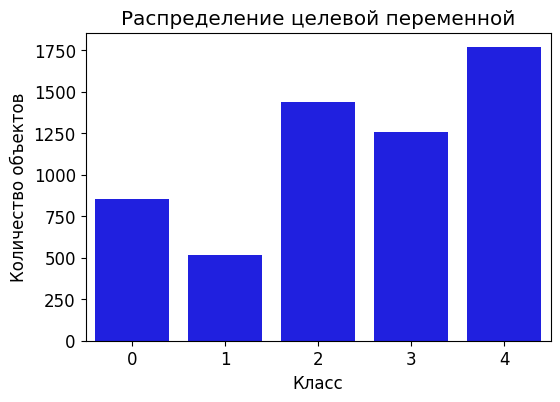

In [56]:
def target_distribution(x):
    value_counts = x.value_counts()
    value_share = x.value_counts(normalize=True)
    print('Количество объектов:')
    print(value_counts)
    print('Доли классов:')
    print(value_share)

    plt.figure(figsize=(6, 4))
    sns.countplot(x=x, color='blue')
    plt.title('Распределение целевой переменной')
    plt.xlabel('Класс')
    plt.ylabel('Количество объектов')
    plt.show()
target_distribution(df['age_category'])

<h3>Анализ целевой переменной</h3>

<ul>
    <li>1. Распределение классов
        <ul>
            <li>Класс 4 - 1766 объектов (30.31%)</li>
            <li>Класс 2 - 1439 объектов (24.70%)</li>
            <li>Класс 3 - 1254 объекта (21.52%)</li>
            <li>Класс 0 - 853 объекта (14.64%)</li>
            <li>Класс 1 - 514 объектов (8.82%)</li>
        </ul>
    </li>

    <li>2. Вывод
        <ul>
            <li>Есть дисбаланс классов</li>
            <li>Меньше всего представлен класс 1</li>
            <li>Используем F1-macro</li>
            <li>Учитываем дисбаланс классов при обучении</li>
            <li>Используем stratified split</li>
        </ul>
    </li>
</ul>

<h3>Обработка пропусков</h3>

In [57]:
def missing_report(df):
    total = len(df)
    for col in df.columns:
        print(col)
        print("\t", "пропусков:", df[col].isna().sum())
        print("\t", f"доля: {round(df[col].isna().sum() / total * 100, 2)}%")
missing_report(df)

user_id
	 пропусков: 0
	 доля: 0.0%
age_category
	 пропусков: 0
	 доля: 0.0%
daytime_вечер
	 пропусков: 0
	 доля: 0.0%
daytime_день
	 пропусков: 0
	 доля: 0.0%
daytime_ночь
	 пропусков: 0
	 доля: 0.0%
daytime_утро
	 пропусков: 0
	 доля: 0.0%
website_category_Category 01
	 пропусков: 0
	 доля: 0.0%
website_category_Category 02
	 пропусков: 0
	 доля: 0.0%
website_category_Category 03
	 пропусков: 0
	 доля: 0.0%
website_category_Category 04
	 пропусков: 0
	 доля: 0.0%
website_category_Category 05
	 пропусков: 0
	 доля: 0.0%
website_category_Category 06
	 пропусков: 0
	 доля: 0.0%
website_category_Category 07
	 пропусков: 0
	 доля: 0.0%
website_category_Category 08
	 пропусков: 0
	 доля: 0.0%
website_category_Category 09
	 пропусков: 0
	 доля: 0.0%
website_category_Category 10
	 пропусков: 0
	 доля: 0.0%
website_category_Category 11
	 пропусков: 0
	 доля: 0.0%
website_category_Category 12
	 пропусков: 0
	 доля: 0.0%
website_category_Category 13
	 пропусков: 0
	 доля: 0.0%
website_category_

Проверим сколько значений теряется при удалении

In [58]:
df_clean = df.dropna()

print("Было:", len(df))
print("Стало:", len(df_clean))
print("Потеря:", len(df) - len(df_clean))
print("Доля потерь:", (len(df) - len(df_clean)) / len(df))

Было: 5826
Стало: 5205
Потеря: 621
Доля потерь: 0.10659114315139032


<li>Потери в случае удаления существенны, удаление приводит к уменьшению объёма более 10%</li>
<b>Вывод</b>
<p>Удаление строк с пропусками нецелесообразно необходимо сохранять данные и обрабатывать пропуски отдельно</p>

<h3>Обработка дубликатов</h3>

In [59]:
def duplicates_report(df, id_col='user_id'):
    full_dup = df.duplicated().sum()
    print("Полные дубликаты строк:", full_dup)
    
    id_dup = df.duplicated(subset=[id_col]).sum()
    print("Дубликаты по id:", id_dup)

    no_id = df.drop(columns=[id_col])
    no_id_dup = no_id.duplicated().sum()
    print("Дубликаты без id:", no_id_dup)
duplicates_report(df)

Полные дубликаты строк: 0
Дубликаты по id: 0
Дубликаты без id: 0


<h5>Дубликатов нет</h5>

<h3> Анализ категориальных  признаков</h3>
<ul>
  <li>Сколько уникальных значений в каждом категориальном признаке.</li>
  <li>Какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.</li>
</ul>

In [60]:
def categorical_analysis(df, cat_cols):
    for col in cat_cols:
        print("Столбец:", col)
        print("Уникальных значений:", df[col].nunique())
        print("Примеры значений:", df[col].unique()[:5])
        print()

In [61]:
cat_cols = ['ads_activity', 'surf_depth', 'primary_device']
categorical_analysis(df, cat_cols)

Столбец: ads_activity
Уникальных значений: 5
Примеры значений: <StringArray>
[nan, 'умеренно', 'редко', 'очень редко', 'очень часто']
Length: 5, dtype: str

Столбец: surf_depth
Уникальных значений: 3
Примеры значений: <StringArray>
['глубоко', 'средне', 'поверхностно', nan]
Length: 4, dtype: str

Столбец: primary_device
Уникальных значений: 4
Примеры значений: <StringArray>
['смартфон', 'ноутбук', 'ПК', 'планшет', nan]
Length: 5, dtype: str



<h5>Вывод</h5>

<P>все признаки обладают небольшой кардинальность для всех подходит OHE</P>

<h3>Анализ выбросов и распределления</h3>

count    5826.000000
mean      182.929111
std        76.390669
min       100.000000
25%       126.000000
50%       169.000000
75%       217.000000
max       853.000000
Name: session_count, dtype: float64
Выбросы:
Количество: 187
Процент: 3.21
Границы: -10.5 353.5
Первые 5 выбросов выше верхней границы: [354 355 355 355 355]
5 максимальных значений: [714 722 808 846 853]


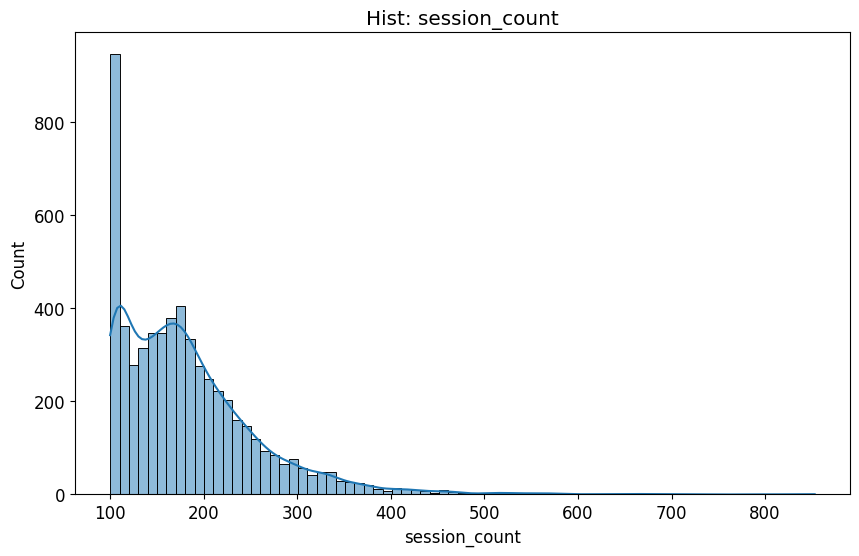

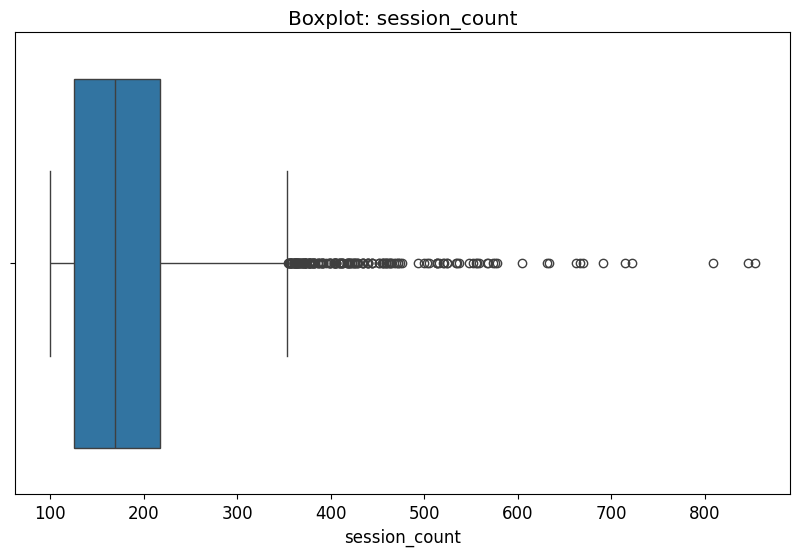

In [62]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers) / len(data) * 100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы:", high_outliers.head(5).values)
    print("5 максимальных значений:", high_outliers.tail(5).values)
    
    sns.histplot(data, kde=True)
    plt.title(f"Hist: {col}")
    plt.show()

    sns.boxplot(x=data)
    plt.title(f"Boxplot: {col}")
    plt.show()
data_review(df, 'session_count')

Довольно большое количество пользователей с выбросами, однако это могут быть пользователи просто с высокой активностью проверим

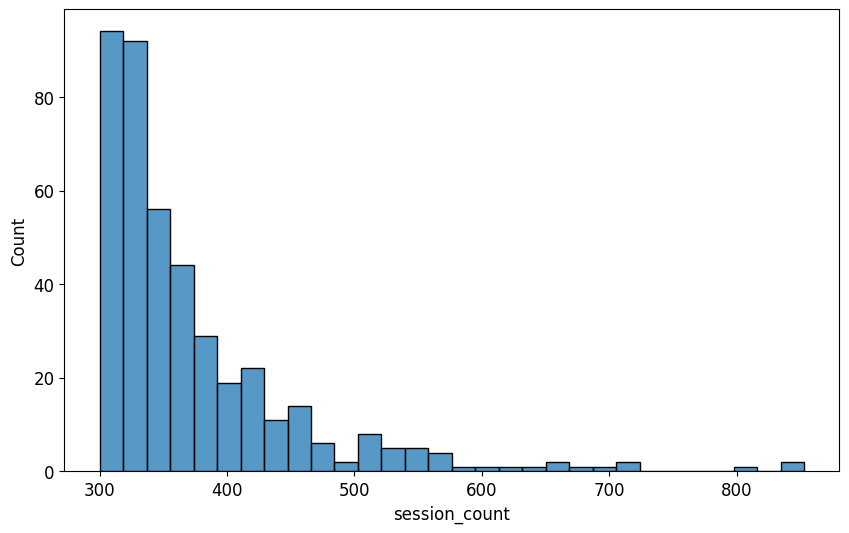

In [63]:
high_activity = df[df['session_count'] >= 300]['session_count']
sns.histplot(high_activity, bins=30)
plt.show()

In [64]:
for i in range(300, 851, 50):
    count = (df['session_count'] >= i).sum()
    print(f"{count} пользователей с активностью выше {i}")

424 пользователей с активностью выше 300
197 пользователей с активностью выше 350
104 пользователей с активностью выше 400
57 пользователей с активностью выше 450
36 пользователей с активностью выше 500
21 пользователей с активностью выше 550
12 пользователей с активностью выше 600
9 пользователей с активностью выше 650
5 пользователей с активностью выше 700
3 пользователей с активностью выше 750
3 пользователей с активностью выше 800
1 пользователей с активностью выше 850


<h3>Вывод высокоактивных пользователей</h3>

<ul>
    <li>Дллинный правый хвост распределения по активности</li>
    <li>424 пользователя имеют активность выше 300 сессий</li>
    <li>Высокие значения (500+) встречаются редко</li>
</ul>
Количество пользователей равномерно уменьшается, но  из за длины правого хвоста необходимо провести логарифмирование для более равномерного распределения

<h3>Корреляции¶</h3>

In [65]:
def phik_corr_matrix(df, interval_cols=None, drop_cols=None):
    data = df.copy()
    
    if drop_cols:
        data = data.drop(columns=drop_cols, errors='ignore')
    
    corr = data.phik_matrix(interval_cols=interval_cols)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr, cmap='coolwarm')
    plt.show()
    
    return corr

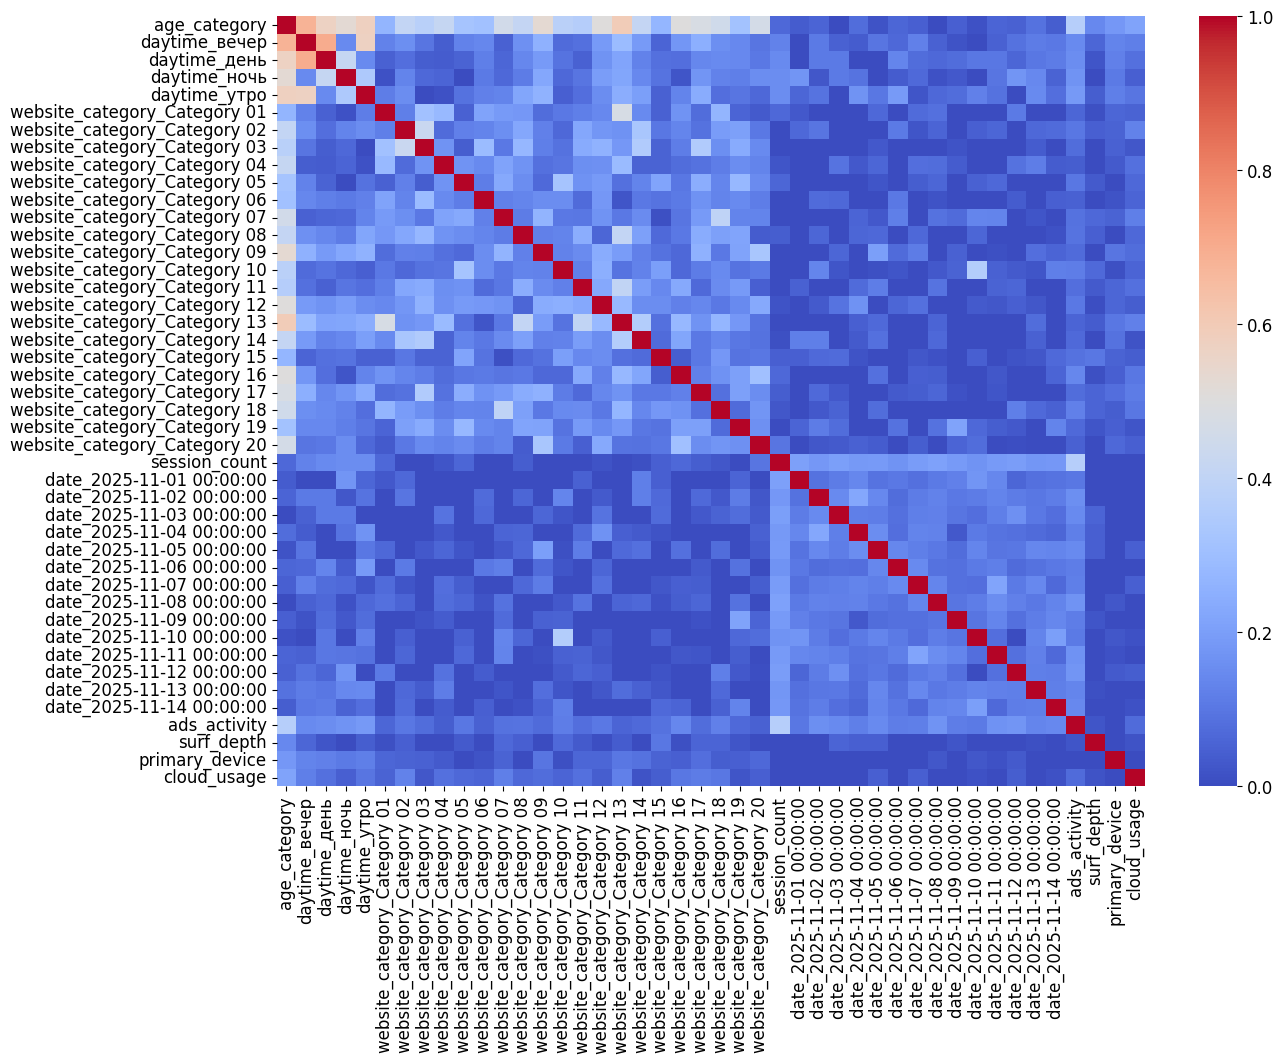

,age_category,daytime_вечер,daytime_день,daytime_ночь,daytime_утро,website_category_Category 01,website_category_Category 02,website_category_Category 03,website_category_Category 04,website_category_Category 05,...,date_2025-11-09 00:00:00,date_2025-11-10 00:00:00,date_2025-11-11 00:00:00,date_2025-11-12 00:00:00,date_2025-11-13 00:00:00,date_2025-11-14 00:00:00,ads_activity,surf_depth,primary_device,cloud_usage
age_category,1.000000,0.682386,0.569928,0.525390,0.576593,0.266043,0.409882,0.378157,0.416316,0.323442,...,0.046734,0.012879,0.054768,0.048132,0.087176,0.041746,0.367874,0.140736,0.183185,0.214420
daytime_вечер,0.682386,1.000000,0.700365,0.147026,0.574051,0.126842,0.157849,0.097162,0.039093,0.127550,...,0.016830,0.000000,0.048624,0.089019,0.112586,0.105411,0.146063,0.058999,0.132313,0.120720
daytime_день,0.569928,0.700365,1.000000,0.416402,0.144613,0.049937,0.079515,0.040807,0.037035,0.051894,...,0.076932,0.097731,0.099381,0.062155,0.098299,0.109916,0.154761,0.023306,0.121429,0.085472
daytime_ночь,0.525390,0.147026,0.416402,1.000000,0.343859,0.015393,0.132178,0.063826,0.056372,0.000000,...,0.029666,0.000000,0.094263,0.174362,0.144520,0.051745,0.171146,0.000000,0.108342,0.045328
daytime_утро,0.576593,0.574051,0.144613,0.343859,1.000000,0.113834,0.154014,0.000000,0.011796,0.086384,...,0.076937,0.122592,0.087835,0.000000,0.146821,0.081480,0.183831,0.042699,0.120165,0.095722
website_category_Category 01,0.266043,0.126842,0.049937,0.015393,0.113834,1.000000,0.120638,0.309363,0.281648,0.048531,...,0.000000,0.000000,0.000000,0.105666,0.000000,0.000000,0.060967,0.009040,0.058923,0.051590
website_category_Category 02,0.409882,0.157849,0.079515,0.132178,0.154014,0.120638,1.000000,0.425834,0.070363,0.123907,...,0.000000,0.043166,0.059520,0.000000,0.065189,0.070665,0.100656,0.046661,0.052423,0.127742
website_category_Category 03,0.378157,0.097162,0.040807,0.063826,0.000000,0.309363,0.425834,1.000000,0.170142,0.042736,...,0.016707,0.000000,0.000000,0.000000,0.036209,0.000000,0.076686,0.000000,0.049960,0.024883
website_category_Category 04,0.416316,0.039093,0.037035,0.056372,0.011796,0.281648,0.070363,0.170142,1.000000,0.170190,...,0.038777,0.000000,0.000000,0.088394,0.113292,0.036265,0.042505,0.000000,0.034905,0.083634
website_category_Category 05,0.323442,0.127550,0.051894,0.000000,0.086384,0.048531,0.123907,0.042736,0.170190,1.000000,...,0.000000,0.049292,0.063258,0.000000,0.000000,0.000000,0.100530,0.033037,0.000000,0.065771


In [66]:
drop_cols = ['user_id']
interval_cols = [x for x in df.columns if df[x].dtype in ["int64", "float64"]]
phik_corr_matrix(df=df, interval_cols=interval_cols, drop_cols=drop_cols)

<h4>1. Связь признаков с целевой переменной (age_category)</h4>
<ul>
  <li>Сильные зависимости (0.5+):
    <ul>
      <li>daytime_вечер - 0.68</li>
      <li>daytime_утро - 0.57</li>
      <li>daytime_день - 0.56</li>
      <li>website_category_Category 09 - 0.53</li>
      <li>website_category_Category 13 - 0.59</li>
    </ul>
  </li>

  <li>Средние зависимости (0.3–0.5):
    <ul>
      <li>ads_activity - 0.37</li>
      <li>многие website_category_* - 0.30–0.45</li>
    </ul>
  </li>

  <li>Слабые зависимости (<0.2):
    <ul>
      <li>session_count - 0.07</li>
      <li>surf_depth - 0.14</li>
      <li>primary_device - 0.18</li>
      <li>cloud_usage - 0.21</li>
    </ul>
  </li>
</ul>

<h4>2. Вывод по признакам</h4>
Возвраст сильнее всего связан с временем и категорией сайта  
</ul>

<h2>Этап 3 Предобработка: Cобираем пайплайн. Делим данные 80/20 тестовую выборку не трогаем до самого конца.</h2>

In [67]:
def split_data(df, target, drop_cols=None, test_size=0.2, random_state=42):
    if drop_cols is None:
        drop_cols = []
    X = df.drop(columns=[target] + drop_cols)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

    print("Размер обучающей выборки:", X_train.shape)
    print("Размер тестовой выборки:", X_test.shape)
    print("Распределение target в train:")
    print(y_train.value_counts(normalize=True))
    print("Распределение target в test:")
    print(y_test.value_counts(normalize=True))

    return X_train, X_test, y_train, y_test

In [68]:
X_train, X_test, y_train, y_test = split_data(df=df, target='age_category')

Размер обучающей выборки: (4660, 44)
Размер тестовой выборки: (1166, 44)
Распределение target в train:
age_category
4    0.303219
2    0.246996
3    0.215236
0    0.146352
1    0.088197
Name: proportion, dtype: float64
Распределение target в test:
age_category
4    0.302744
2    0.246998
3    0.215266
0    0.146655
1    0.088336
Name: proportion, dtype: float64


Данные успешно разделены с сохранением распределения целевой переменной в train / test

In [69]:
def prepare_pipeline(num_cols, cat_cols, ordinal_cols=None, target_cols=None, missing_num="median",
                     scaling="standard", missing_cat='most_frequent', encode="onehot", collinear_cols=None):
    if collinear_cols is None:
        collinear_cols = []
    if ordinal_cols is None:
        ordinal_cols = []
    if target_cols is None:
        target_cols = []
    
    num_cols = [c for c in num_cols if c not in collinear_cols]
    cat_cols = [c for c in cat_cols if c not in collinear_cols]
    target_cols = [c for c in target_cols if c not in collinear_cols]
    
    num_steps = [("imputer", SimpleImputer(strategy=missing_num))]
    if scaling == "standard":
        num_steps.append(("scaler", StandardScaler()))
    elif scaling == "minmax":
        num_steps.append(("scaler", MinMaxScaler()))
    num_pipe = Pipeline(num_steps)

    cat_steps = [("imputer", SimpleImputer(strategy=missing_cat))]
    if encode == "onehot":
            cat_steps.append(("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)))
    cat_pipe = Pipeline(cat_steps)

    transformers = [("num", num_pipe, num_cols),
                    ("cat", cat_pipe, cat_cols),]

    for col, categories in ordinal_cols:
        ordinal_pipe = Pipeline([ ("imputer", SimpleImputer(strategy="most_frequent")),
                                  ("encoder", OrdinalEncoder(categories=[categories]))])
        
        transformers.append(("ord_"+col, ordinal_pipe, [col]))

    if target_cols:
        target_pipe = Pipeline([("encoder", TargetEncoder(handle_unknown="value", handle_missing="value"))]) 
        transformers.append(("target", target_pipe, target_cols))

    preprocessor = ColumnTransformer(transformers)
    return preprocessor

In [70]:
num_cols = ['session_count']

pass_cols = [col for col in X_train.columns if ('daytime_' in col or 'website_category_' in col or 'date_' in col)]

cat_cols = ['ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']

preprocessor = prepare_pipeline(
    num_cols=num_cols,
    cat_cols=cat_cols,
    missing_num='median',
    scaling='standard',
    missing_cat='most_frequent',
    encode='onehot'
)

transformers = preprocessor.transformers

preprocessor = ColumnTransformer(transformers=[*transformers, ('pass', 'passthrough', pass_cols)])

X_train_prepared = preprocessor.fit_transform(X_train.drop(columns=['user_id']), y_train)
X_test_prepared = preprocessor.transform(X_test.drop(columns=['user_id']))

print("Размер после предобработки:")
print("Train:", X_train_prepared.shape)
print("Test:", X_test_prepared.shape)

Размер после предобработки:
Train: (4660, 53)
Test: (1166, 53)


<h4>Подготовка данных и разбиение выборки</h4>

<ul>
    <li>Данные были разделены на обучающую и тестовую выборки с помощью <code>train_test_split</code>.</li>
    <li>Использовали <code>stratify=y</code>, благодаря чему распределение <code>age_category</code> сохранилось в train и test выборке.</li>
    <li>Был построен пайплайн предобработки данных</li>
    <li>Для числового признака <code>session_count</code>:
        <ul>
            <li>пропуски заполнялись медианой;</li>
            <li>масштабирование <code>StandardScaler</code>.</li>
        </ul>
    </li>
    <li>Для категориальных признаков: <code>ads_activity</code>, <code>surf_depth</code>, <code>primary_device</code>, <code>cloud_usage</code>:
        <ul>
            <li>заполнение пропусков наиболее частым значением;</li>
            <li><code>One-Hot Encoding</code>.</li>
        </ul>
    </li>
    <li>После One-Hot Encoding количество признаков увеличилось, так как категориальные признаки были преобразованы в бинарные колоноки.</li>
    <li>Размеры итоговых датасетов после предобработки:
        <ul>
            <li>Train: <code>(4660, 53)</code></li>
            <li>Test: <code>(1166, 53)</code></li>
        </ul>
    </li>
</ul>

<h2>Этап 4 Отбор признаков: используем методы-обёртки для поиска оптимального набора признаков.</h2>

In [71]:
def feature_select(X_train, y_train, preprocessor, methods, cols_num):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    results = {}
    feature_counts = [int(cols_num * 0.25), int(cols_num * 0.50), int(cols_num * 0.75), cols_num]
    
    for method in methods:
        for k in feature_counts:
            if method == "kbest":
                pipe = Pipeline([
                    ("preprocessor", preprocessor),
                    ("selector", SelectKBest(score_func=mutual_info_classif, k=k)),
                    ("model", LogisticRegression(max_iter=5000, random_state=42))
                ])
                
            elif method == "rfe":
                pipe = Pipeline([
                    ("preprocessor", preprocessor),
                    ("selector", RFE(estimator=LogisticRegression(max_iter=1000, random_state=42), n_features_to_select=k, step=0.2)),
                    ("model", LogisticRegression(max_iter=5000, random_state=42))
                ])

            else:
                print("Метод", method, "не реализован")

            scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring={"f1_macro": "f1_macro"}, n_jobs=-1)
            results[method, k] = scores["test_f1_macro"].mean()

            print(method)
            print("Количество признаков:", k)
            print("F1-macro:", scores["test_f1_macro"].mean())
            print()

    return results

In [72]:
results = feature_select(X_train=X_train, y_train=y_train, preprocessor=preprocessor, methods=["kbest", "rfe"], cols_num=53)

kbest
Количество признаков: 13
F1-macro: 0.6100914784002096

kbest
Количество признаков: 26
F1-macro: 0.6704307395532066

kbest
Количество признаков: 39
F1-macro: 0.6758794229352654

kbest
Количество признаков: 53
F1-macro: 0.6742384124653469

rfe
Количество признаков: 13
F1-macro: 0.6155291908785978

rfe
Количество признаков: 26
F1-macro: 0.6725968868710612

rfe
Количество признаков: 39
F1-macro: 0.6679761143707988

rfe
Количество признаков: 53
F1-macro: 0.6742384124653469



<h4>Вывод по отбору признаков</h4>

<ul>
    <li>Лучший результат - SelectKBest при использовании 26 признаков: F1-macro = 0.676</li>
    <li>Улучшение при уменьшении числа признаков есть</li>
    <li>Нужно использовать отбор признаков SelectKBest на 26 признаков</li>
</ul>

<h2>Этап 5 Базовая модель: обучаем DummyClassifier и многоклассовые модели OvR, OvO, multinomial LogisticRegression модели.</h2>

In [73]:
def evaluate_models(models, X, y, preprocessor, metrics, selector=None):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []
    scoring = {}
    
    for metric in metrics:
        scoring[metric] = metric

    for name, model in models.items():
        steps = []
        if preprocessor is not None:
            steps.append(("preprocessor", preprocessor))
        if selector is not None:
            steps.append(("selector", selector))
        steps.append(("model", model))
        pipe = Pipeline(steps)
        scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        result = {"model": name}
        for metric in metrics:
            result[metric] = scores["test_" + metric].mean()
        results.append(result)
        print(name)
        for metric in metrics:
            print(metric + ":", scores["test_" + metric].mean())
        print()
        pipe.fit(X, y)
        y_pred = pipe.predict(X)
        conf = confusion_matrix(y, y_pred)
        print(conf)
        sns.heatmap(conf, annot=True)
        plt.show()

    return pd.DataFrame(results)

Dummy
accuracy: 0.3032188841201717
precision_macro: 0.06064377682403434
recall_macro: 0.2
f1_macro: 0.09306762666015822

[[   0    0    0    0  682]
 [   0    0    0    0  411]
 [   0    0    0    0 1151]
 [   0    0    0    0 1003]
 [   0    0    0    0 1413]]


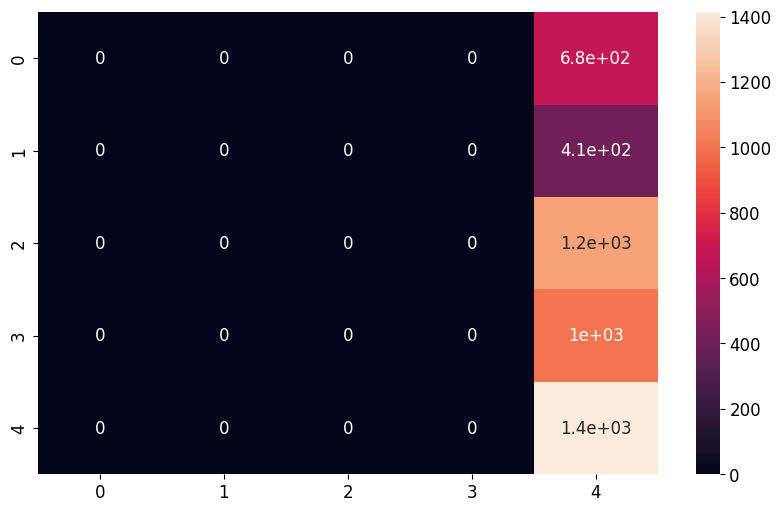

OvR LogisticRegression
accuracy: 0.7609442060085837
precision_macro: 0.7375324210933253
recall_macro: 0.6569183175661675
f1_macro: 0.6402028468342128

[[ 541    4   93   12   32]
 [  94   24  193   12   88]
 [  39    2 1011   35   64]
 [  26    1   83  719  174]
 [   6    2   35   33 1337]]


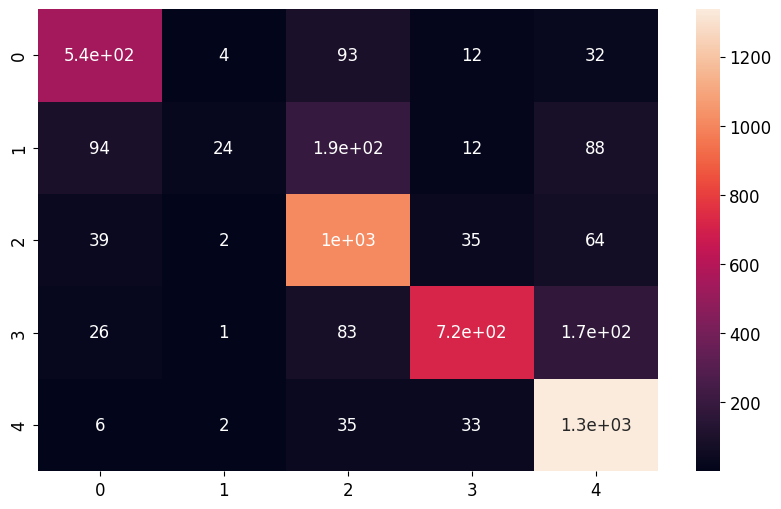

OvO LogisticRegression
accuracy: 0.7319742489270386
precision_macro: 0.6790137366711445
recall_macro: 0.6283249696034794
f1_macro: 0.6104644446820922

[[ 503    6  123   15   35]
 [  83   27  211   18   72]
 [  59    2  991   34   65]
 [  29    1  118  698  157]
 [   7    1   52   47 1306]]


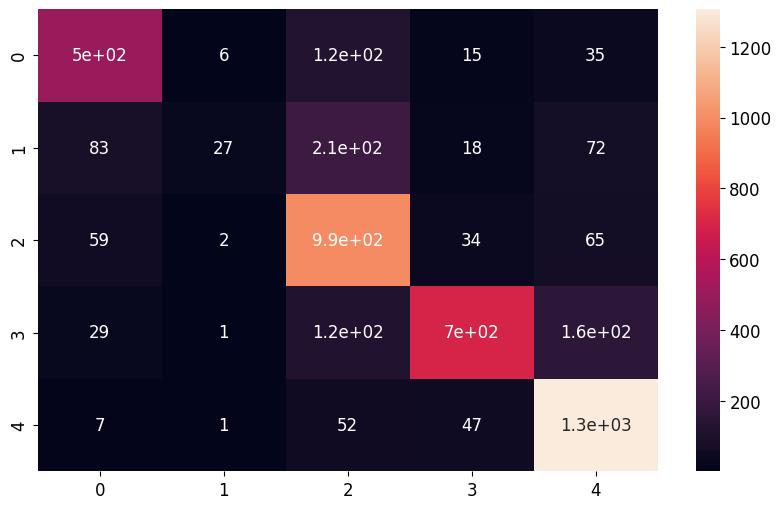

Multinomial LogisticRegression
accuracy: 0.7804721030042918
precision_macro: 0.7590870733800837
recall_macro: 0.6838667446580463
f1_macro: 0.6742384124653469

[[ 557    7   78   13   27]
 [  88   59  177   18   69]
 [  35    7 1015   41   53]
 [  22    4   74  774  129]
 [   8    2   34   51 1318]]


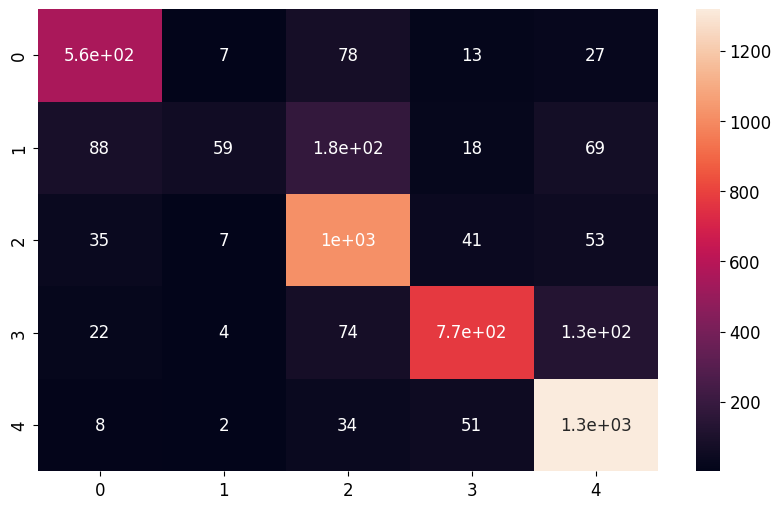

LinearSVC
accuracy: 0.8238197424892704
precision_macro: 0.8144233337053194
recall_macro: 0.753067739747624
f1_macro: 0.758315541006221

[[ 604   11   44    9   14]
 [  83  135  115   23   55]
 [  29   13 1021   53   35]
 [  15    5   60  809  114]
 [   7    4   20   52 1330]]


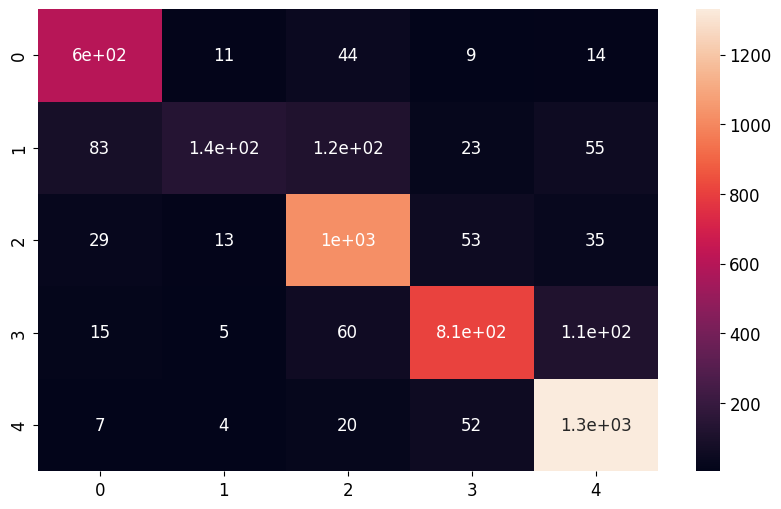

SVC linear
accuracy: 0.8042918454935621
precision_macro: 0.7918604119993384
recall_macro: 0.7161626750105445
f1_macro: 0.7114497975612792

[[ 580   17   65    7   13]
 [  85  102  163   19   42]
 [  36    9 1041   33   32]
 [  18    4   71  797  113]
 [   8    3   27   57 1318]]


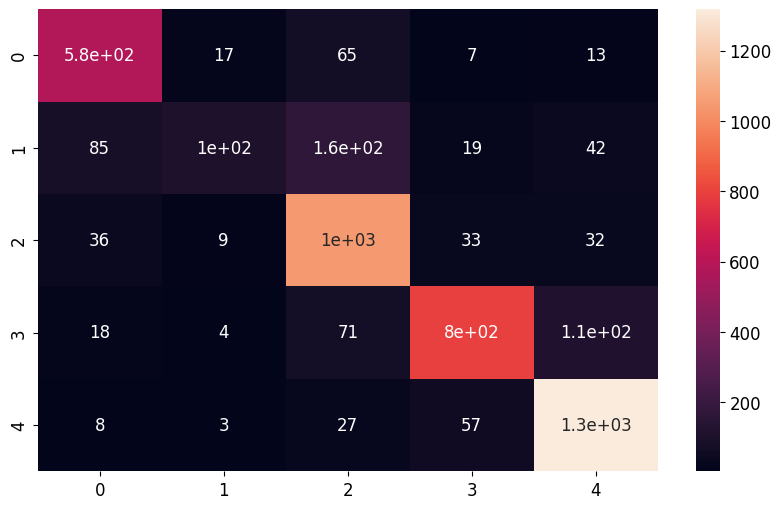

SVC rbf
accuracy: 0.5626609442060085
precision_macro: 0.5612162998796025
recall_macro: 0.4767773811473132
f1_macro: 0.45734102601554366

[[ 429   13  173   21   46]
 [ 107   25  198   14   67]
 [  66    0  935   49  101]
 [  31    0  236  409  327]
 [  15    0  114   82 1202]]


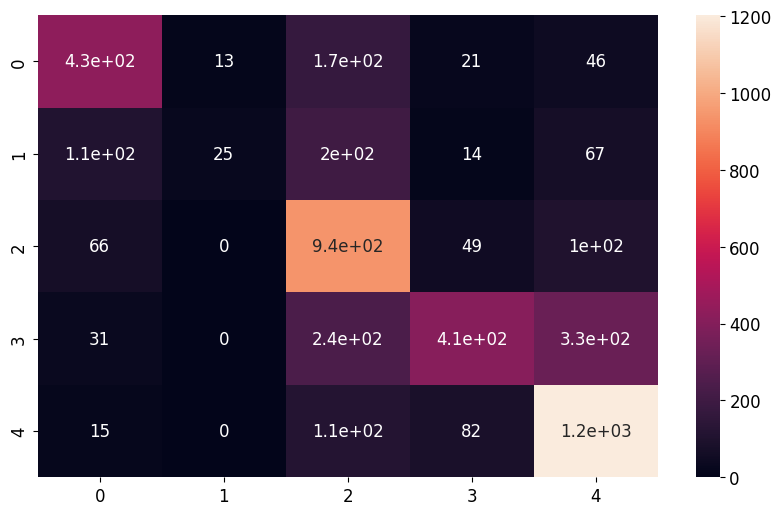

SVC poly
accuracy: 0.5418454935622317
precision_macro: 0.516044336431122
recall_macro: 0.4713202246906885
f1_macro: 0.46256201502423977

[[ 459   16  130   15   62]
 [ 103   67  164   23   54]
 [  55    4  909   64  119]
 [  36    5  235  438  289]
 [  16    4  112   84 1197]]


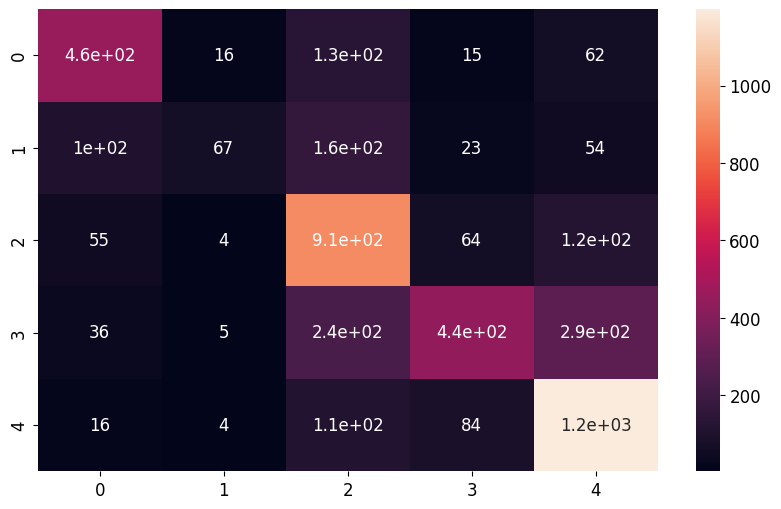

SVC sigmoid
accuracy: 0.3109442060085837
precision_macro: 0.3012869533773498
recall_macro: 0.2960812201837579
f1_macro: 0.2769810107386475

[[167 138 265  43  69]
 [ 64 122 167  31  27]
 [127 200 610 117  97]
 [132 153 445 149 124]
 [211 187 467 171 377]]


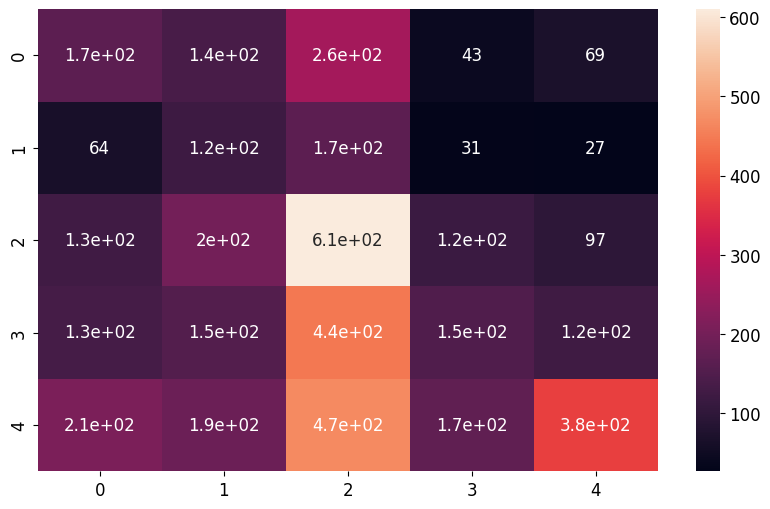

In [74]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "OvR LogisticRegression": OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "OvO LogisticRegression": OneVsOneClassifier(LogisticRegression(max_iter=1000, random_state=42)),
    "Multinomial LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),  
    "LinearSVC": LinearSVC(random_state=42),
    "SVC linear": SVC(kernel="linear", random_state=42),
    "SVC rbf": SVC(kernel="rbf", random_state=42),
    "SVC poly": SVC(kernel="poly", degree=5, random_state=42),
    "SVC sigmoid": SVC(kernel="sigmoid", random_state=42)
}
metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
results = evaluate_models(models, X_train.drop(columns=['user_id']), y_train, preprocessor, metrics)

<h4>Вывод</h4>

<ul>
    <li>
        Среди моделей LogisticRegression лучшая multinomial LogisticRegression:
        <ul>
            <li>Accuracy = 0.780 - модель правильно определяет класс у 78% объектов</li>
            <li>Precision-macro = 0.76 у модели не много ложных срабатываний</li>
            <li>Recall-macro = 0.684 модель находит 68% объектов каждого класса</li>
            <li>F1-macro = 0.675 баланс между precision и recall лучший среди логистических моделей</li>
            <li>OvR и OvO LogisticRegression дают результат хуже по всем метрикам - менее стабильное разделение классов</li>
        </ul>
    </li>
    <li>
        Среди моделей SVM лучшая LinearSVC:
        <ul>
            <li>Accuracy = 0.824 - модель правильно определяет класс у 82% объектов</li>
            <li>Precision-macro = 0.814 - у модели не много ложных срабатываний</li>
            <li>Recall-macro = 0.753 - модель находит 75% объектов каждого класса</li>
            <li>F1-macro = 0.759 - лучший баланс между precision и recall среди всех моделей</li>
        </ul>
        SVC с линейным ядром показал близкие к LinearSVC результаты:
        <ul>
            <li>Accuracy = 0.804</li>
            <li>F1-macro = 0.711</li>
        </ul>
        SVC с ядрами rbf, poly и sigmoid показали результаты более слабые чем остальные модели:
        <ul>
            <li>RBF и polynomial ядра начали хуже разделять классы и допустили большое количество ошибок </li>
            <li>Sigmoid ядро показало результат accuracy, близкий к DummyClassifier, что означает непригодность модели для текущей задачи</li>
        </ul>
    </li>
    <li>После OHE-преобразования данные стали близки к линейному разделению, поэтому линейные модели оказались эффективнее</li>
    <li>Лучшей стала модель LinearSVC</li>
    <li>Для данной задачи особенно важен recall несовершеннолетних(класс 0), так как ошибка, при которой несовершеннолетний пользователь определяется как совершеннолетний, является наиболее грубой в задаче, поэтому в дальнейшем необходимо изменить для повышение recall младших возрастных классов, даже если это приведёт к снижению precision.</li>
</ul>

<h2>Этап 6 Новые признаки: генерируем дополнительные признаки на основе уже имеющихся, проверяем помогают ли они модели.</h2>

Создадим новые признаки и проверим как они повлияют на метрики лучших моделей:
<ul>
    <li><code>weekend_activity</code> - суммарная доля активности в выходные дни</li>
    <li><code>avg_day_activity</code> - <code>session_count</code> деленное на количество дней в которых была активность</li>
    <li><code>category_time_prefer</code> - какая категория используется во время суток основной активности</li>
    <li><code>category_use</code> - <code>session_count</code> умноженный на долю по категории сайта</li>
    <li><code>daytime_use</code> - <code>session_count</code> умноженный на долю по времени суток</li>
</ul>

In [75]:
def add_features(X, visits_df=None):
    if visits_df is None:
        visits_df = visits
    X = X.copy()
    date_cols = [col for col in X.columns if "date_" in col]
    
    weekend_days = [col for col in date_cols if pd.to_datetime(col.replace("date_", "")).dayofweek in [5, 6]]
    X["weekend_activity"] = 0
    for col in weekend_days:
        X["weekend_activity"] += X[col]
        
    X["active_days"] = (X[date_cols] > 0).sum(axis=1)
    X["avg_day_activity"] = X["session_count"] / X["active_days"]
    daytime_cols = ["daytime_утро", "daytime_день", "daytime_вечер", "daytime_ночь"]
    X["main_daytime"] = (X[daytime_cols].idxmax(axis=1).str.replace("daytime_", ""))
    visits_temp = visits_df.merge(X[["user_id", "main_daytime"]], on="user_id", how="left")
    visits_temp = visits_temp[visits_temp["daytime"] == visits_temp["main_daytime"]]
    category_time_prefer = (visits_temp.groupby(["user_id", "website_category"]).size().unstack(fill_value=0).idxmax(axis=1).reset_index(name="category_time_prefer"))
    X = X.merge(category_time_prefer, on="user_id", how="left")
    website_category_cols = [col for col in X.columns if "website_category_" in col]
    for col in website_category_cols:
        X[col + "_use"] = X["session_count"] * X[col]
    
    daytime_cols = [col for col in X.columns if "daytime_" in col]
    for col in daytime_cols:
        X[col + "_use"] = X["session_count"] * X[col]
        
    return X

In [76]:
X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

num_cols = ["session_count", "weekend_activity", "avg_day_activity"]

pass_cols = [col for col in X_train_fe.columns if ("daytime_" in col or
                                                   "website_category_" in col or
                                                   "date_" in col or
                                                   "_use" in col)]

cat_cols = ["ads_activity", "surf_depth", "primary_device", "cloud_usage", "category_time_prefer"]

preprocessor = prepare_pipeline(
    num_cols=num_cols,
    cat_cols=cat_cols,
    missing_num='median',
    scaling='standard',
    missing_cat='most_frequent',
    encode='onehot'
)

transformers = preprocessor.transformers

preprocessor = ColumnTransformer(transformers=[*transformers, ('pass', 'passthrough', pass_cols)])

X_train_prepared = preprocessor.fit_transform(X_train_fe, y_train)
X_test_prepared = preprocessor.transform(X_test_fe)

print("Размер после предобработки:")
print("Train:", X_train_prepared.shape)
print("Test:", X_test_prepared.shape)

results = feature_select(X_train=X_train_fe.drop(columns=['user_id']), y_train=y_train, preprocessor=preprocessor, methods=["kbest"], cols_num=99)

Размер после предобработки:
Train: (4660, 99)
Test: (1166, 99)
kbest
Количество признаков: 24
F1-macro: 0.6706537435055759

kbest
Количество признаков: 49
F1-macro: 0.8028701937278498

kbest
Количество признаков: 74
F1-macro: 0.8110303678695517

kbest
Количество признаков: 99
F1-macro: 0.8108703309772812



<ul>
    <li>После добавления новых признаков размерность увеличилась до 99 </li>
    <li>По результатам отбора признаков видно, что не все признаки одинаково полезны для модели.</li>
    <li>Метод <code>kbest</code> показывает, что качество модели растёт при увеличении числа признаков, но после 74 признаков улучшение практически прекращается (F1-macro стабилизируется около 0.81).</li>
    <li>В данных есть часть избыточных признаков, которые не дают дополнительного прироста качества.</li>
    <li>Наиболее устойчивое качество достигается при использовании примерно 70–100% признаков</li>
    <li>В дальнейшем имеет смысл использовать метод отбора признаков kbest с 74 признаками</li>
</ul>

In [78]:
models = {
    "LinearSVC": LinearSVC(),
    "Multinomial LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),  
}

LinearSVC
accuracy: 0.832618025751073
precision_macro: 0.8139492054872998
recall_macro: 0.783036827638435
f1_macro: 0.7921360590300683

[[ 592   20   47   12   11]
 [  68  192   90   22   39]
 [  36   30  998   50   37]
 [  15    7   48  829  104]
 [   6    6   31   54 1316]]


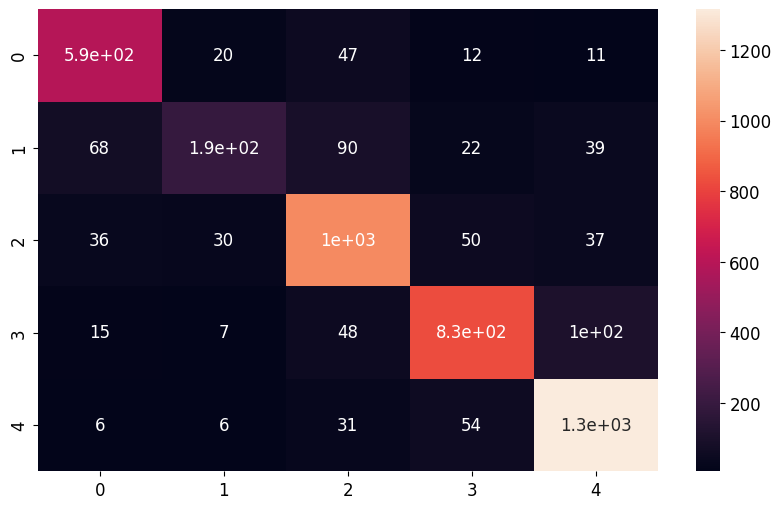

Multinomial LogisticRegression
accuracy: 0.8469957081545065
precision_macro: 0.8214659417375744
recall_macro: 0.8119697964706628
f1_macro: 0.8156176499578258

[[ 601   31   37    5    8]
 [  48  252   72   15   24]
 [  23   50  998   45   35]
 [   9   12   47  852   83]
 [   8   12   28   77 1288]]


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


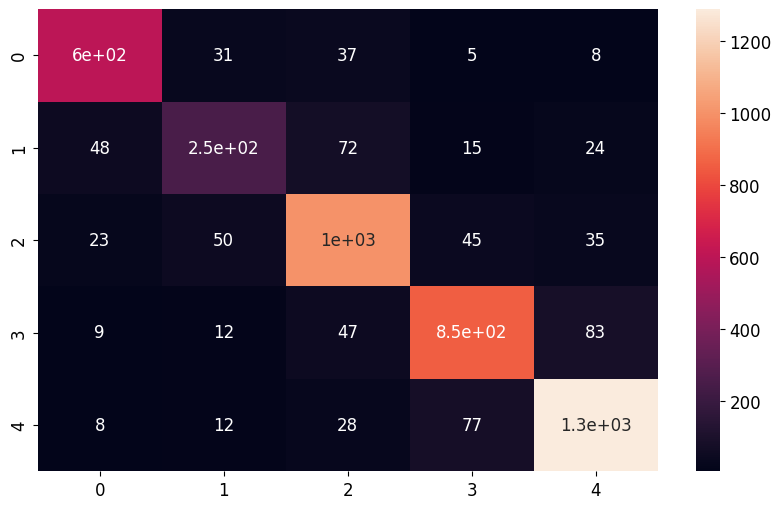

In [79]:
selector = SelectKBest(score_func=mutual_info_classif, k=74)
results = evaluate_models(models, X_train_fe, y_train, preprocessor, ["accuracy", "precision_macro", "recall_macro", "f1_macro"], selector=selector)

<h2>Этап 7 Подбор гиперпараметров: перебираем параметры, сравниваем результаты в таблице, выбираем лучшую конфигурацию.</h2>

In [89]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=74)),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

logreg_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

grid_logreg = GridSearchCV(
    estimator=logreg_pipe,
    param_grid=logreg_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_logreg.fit(X_train_fe, y_train)

results.append(
    pd.DataFrame(grid_logreg.cv_results_).assign(model="LogReg")
)

svc_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=74)),
    ("model", LinearSVC())
])

svc_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

grid_svc = GridSearchCV(
    estimator=svc_pipe,
    param_grid=svc_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
grid_svc.fit(X_train_fe, y_train)

results.append(pd.DataFrame(grid_svc.cv_results_).assign(model="LinearSVC"))

all_models = pd.concat(results, ignore_index=True)

top10 = all_models.sort_values("mean_test_score", ascending=False).head(10)[["model", "params", "mean_test_score", "std_test_score", "rank_test_score"]]

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)

print("\nТОП-10 моделей:")
display(top10)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting 5 folds for each of 8 candidates, totalling 40 fits

ТОП-10 моделей:


,model,params,mean_test_score,std_test_score,rank_test_score
6,LogReg,"{'model__C': 10, 'model__class_weight': None}",0.815163,0.018009,1
4,LogReg,"{'model__C': 1, 'model__class_weight': None}",0.813959,0.018536,2
2,LogReg,"{'model__C': 0.1, 'model__class_weight': None}",0.813600,0.014870,3
0,LogReg,"{'model__C': 0.01, 'model__class_weight': None}",0.811628,0.012981,4
3,LogReg,"{'model__C': 0.1, 'model__class_weight': 'balanced'}",0.811239,0.021629,5
5,LogReg,"{'model__C': 1, 'model__class_weight': 'balanced'}",0.811188,0.018121,6
1,LogReg,"{'model__C': 0.01, 'model__class_weight': 'balanced'}",0.807505,0.017504,7
9,LinearSVC,"{'model__C': 0.01, 'model__class_weight': 'balanced'}",0.807245,0.015039,1
7,LogReg,"{'model__C': 10, 'model__class_weight': 'balanced'}",0.807043,0.018895,8
11,LinearSVC,"{'model__C': 0.1, 'model__class_weight': 'balanced'}",0.806375,0.019521,2


Из 10 лучших конфигураций 8 занимают модели LogisticRegression, что подтверждает её преимущество по качеству. В среднем она показывает более высокие значения метрик чем LinearSVC. 

Далее проведём анализ влияния гиперпараметров на recall класса 0, так как в рамках задачи этот показатель является важным. При этом будем учитывать, чтобы улучшение recall не приводило к существенной потере по другим метрикам. Построим кривую precision-recall для задачи класс 0 или не 0

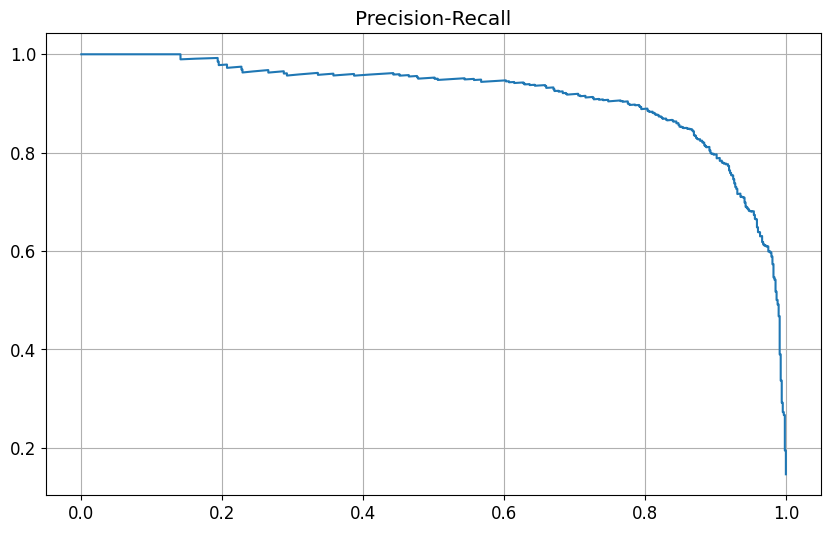

In [88]:
pipe = Pipeline([("preprocessor", preprocessor),
                 ("selector", SelectKBest(score_func=mutual_info_classif, k=74)),
                 ("model", LogisticRegression(random_state=42, max_iter=10000))
])

pipe.fit(X_train_fe, y_train)
y_proba = cross_val_predict(pipe, X_train_fe, y_train, cv=5, method="predict_proba", n_jobs=-1)
y_train_bin = (y_train == 0).astype(int)
y_proba_0 = y_proba[:, 0]

precision, recall, thresholds = precision_recall_curve(y_train_bin, y_proba_0)

plt.plot(recall, precision)

plt.title("Precision-Recall")

plt.grid()
plt.show()

До recall 0.9 precision сохраняется на уровне 0.83 - 1, что говорит о хорошем разделении класса 0 и остальных классов при пороге target_recall = 0.90

0.3078364176548037
Accuracy: 0.8424892703862661
Precision macro: 0.8184717141564315
Recall macro: 0.805969553785556
F1 macro: 0.8095221924186651
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       682
           1       0.71      0.55      0.62       411
           2       0.84      0.85      0.85      1151
           3       0.85      0.82      0.84      1003
           4       0.89      0.91      0.90      1413

    accuracy                           0.84      4660
   macro avg       0.82      0.81      0.81      4660
weighted avg       0.84      0.84      0.84      4660

[[ 615   20   32    7    8]
 [  74  225   70   16   26]
 [  42   48  977   47   37]
 [  20   10   51  827   95]
 [  15   15   30   71 1282]]


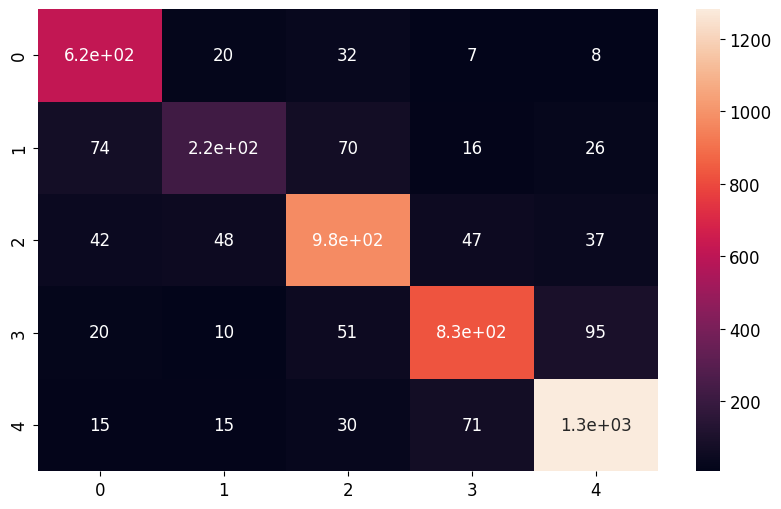

In [90]:
target_recall = 0.90
idx = np.argmin(np.abs(recall - target_recall))
threshold = thresholds[idx]
print(threshold)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_true_all = []
y_pred_all = []
for train_idx, val_idx in cv.split(X_train_fe, y_train):
    X_tr = X_train_fe.iloc[train_idx]
    X_val = X_train_fe.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]
    pipe.fit(X_tr, y_tr)
    y_proba_val = pipe.predict_proba(X_val)
    y_pred = np.argmax(y_proba_val, axis=1)
    p0 = y_proba_val[:, 0]
    y_pred[p0 >= threshold] = 0
    y_true_all.extend(y_val)
    y_pred_all.extend(y_pred)


print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Precision macro:", precision_score(y_true_all, y_pred_all, average="macro"))
print("Recall macro:", recall_score(y_true_all, y_pred_all, average="macro"))
print("F1 macro:", f1_score(y_true_all, y_pred_all, average="macro"))

print(classification_report(y_true_all, y_pred_all))

conf = confusion_matrix(y_true_all, y_pred_all)
print(conf)

sns.heatmap(conf, annot=True)
plt.show()

<h4>Вывод по этапу 7</h4>

<p>
Лучшие результаты показала модель <code>LogisticRegression</code>. Из 10 лучших конфигураций 8 принадлежат этой модели
Наилучшая конфегурация: LogisticRegression(C=1, class_weight=None)</p>

<p>
Дополнительно был проведён анализ распознавания класса 0, так как recall для этого класса является важным показателем.
Для этого была построена Precision-Recall кривая по вероятностям класса 0. Модель сохраняет высокую точность при увеличении recall до 0.9.
</p>

<p> Итоговые метрики: </p>

<ul>
    <li>Accuracy: 0.845</li>
    <li>Precision macro: 0.82</li>
    <li>Recall macro: 0.81</li>
    <li>F1 macro: 0.813</li>
    <li>Recall класса 0: 0.9</li>
</ul>

<p>
Модель хорошо распознаёт класс 0 без ухудшения остальных метрик, поэтому выбранная модель подходит для задачи.
</p>

<h2>Этап 8 Финальная модель: обучаем лучшую модель на всех тренировочных данных, замеряем качество на тестовой выборке, сохраняем модель и пайплайн через joblib.<h2>

Accuracy: 0.823327615780446
Precision macro: 0.7988279329382172
Recall macro: 0.7897424739818802
F1 macro: 0.7922880886834994
              precision    recall  f1-score   support

           0       0.74      0.84      0.79       171
           1       0.70      0.57      0.63       103
           2       0.82      0.83      0.82       288
           3       0.85      0.82      0.83       251
           4       0.89      0.89      0.89       353

    accuracy                           0.82      1166
   macro avg       0.80      0.79      0.79      1166
weighted avg       0.82      0.82      0.82      1166

[[144   7  17   2   1]
 [ 28  59  12   2   2]
 [ 11  10 238  13  16]
 [  8   2  14 206  21]
 [  3   6  11  20 313]]


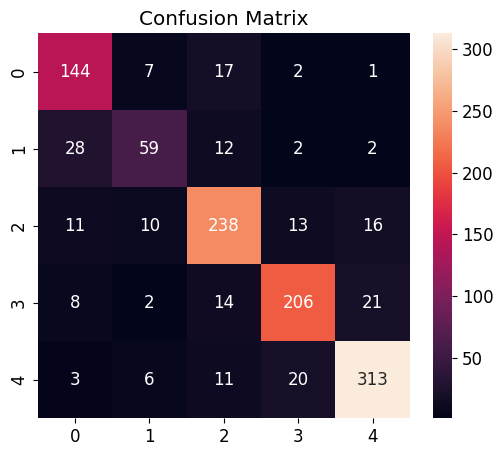

In [91]:
best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=mutual_info_classif, k=74)),
    ("model", LogisticRegression(C=1, class_weight=None, max_iter=5000, random_state=42))
])

best_model.fit(X_train_fe.drop(columns=["user_id"]), y_train)
y_proba = best_model.predict_proba(X_test_fe)
y_pred = np.argmax(y_proba, axis=1)
p0 = y_proba[:, 0]
threshold = 0.31

y_pred[p0 >= threshold] = 0

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision macro:", precision_score(y_test, y_pred, average="macro"))
print("Recall macro:", recall_score(y_test, y_pred, average="macro"))
print("F1 macro:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

print(cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.show()

In [92]:
train_columns = X_train_fe.drop(columns=["user_id"]).columns.tolist()

def build_features(users_df, visits_df, ads_activity_df, surf_depth_df, primary_device_df, cloud_usage_df):

    users_df = users_df.drop_duplicates()
    ads_activity_df = ads_activity_df.drop_duplicates()
    visits_df = visits_df.copy()
    visits_df['date'] = pd.to_datetime(visits_df['date'])

    profiles = create_profiles(df=visits_df, group_col='user_id', cat_cols=['daytime', 'website_category'], num_cols=[])
    profiles = profiles.join(visits_df.groupby('user_id')['session_id'].count().rename('session_count'))

    profiles = profiles.join(create_profiles(df=visits_df, group_col='user_id', cat_cols=['date'], num_cols=[]))

    df = users_df.copy()
    df = df.join(profiles, on='user_id')
    df = df.merge(ads_activity_df, on='user_id', how='left')
    df = df.merge(surf_depth_df, on='user_id', how='left')
    df = df.merge(primary_device_df, on='user_id', how='left')
    df = df.merge(cloud_usage_df, on='user_id', how='left')
    df = add_features(df, visits_df=visits_df)

    df = df.set_index('user_id').loc[users_df['user_id']].reset_index()

    return df


def predict(users_df, visits_df, ads_activity_df, surf_depth_df, primary_device_df, cloud_usage_df, artifacts_path="best_model.pkl"):
    loaded = joblib.load(artifacts_path)
    model = loaded["model"]
    threshold = loaded["threshold_class_0"]
    train_columns = loaded["train_columns"]

    X_new = build_features(users_df, visits_df, ads_activity_df, surf_depth_df, primary_device_df, cloud_usage_df)
    X_new = X_new.drop(columns=["user_id"])
    for col in train_columns:
        if col not in X_new.columns:
            X_new[col] = 0
    X_new = X_new[train_columns]

    proba = model.predict_proba(X_new)
    pred = np.argmax(proba, axis=1)
    pred[proba[:, 0] >= threshold] = 0

    return pred

In [93]:
model_artifacts = {
    "model": best_model,
    "threshold_class_0": threshold,
    "train_columns": train_columns,
    "create_profiles": create_profiles,
    "add_features": add_features,
    "build_features": build_features,
    "predict": predict
}

joblib.dump(model_artifacts, "best_model.pkl")
loaded = joblib.load("best_model.pkl")
predict_loaded = loaded["predict"]
test_user_ids_ordered = X_test['user_id'].tolist()
users_test = users.set_index('user_id').loc[test_user_ids_ordered].reset_index()
y_pred_inference = predict_loaded(
    users_df=users_test,
    visits_df=visits[visits['user_id'].isin(test_user_ids_ordered)],
    ads_activity_df=ads_activity[ads_activity['user_id'].isin(test_user_ids_ordered)],
    surf_depth_df=surf_depth[surf_depth['user_id'].isin(test_user_ids_ordered)],
    primary_device_df=primary_device[primary_device['user_id'].isin(test_user_ids_ordered)],
    cloud_usage_df=cloud_usage[cloud_usage['user_id'].isin(test_user_ids_ordered)]
)

print("F1 macro:", f1_score(y_test, y_pred_inference, average="macro"))
print("Accuracy:", accuracy_score(y_test, y_pred_inference))
print(classification_report(y_test, y_pred_inference))

F1 macro: 0.7922880886834994
Accuracy: 0.823327615780446
              precision    recall  f1-score   support

           0       0.74      0.84      0.79       171
           1       0.70      0.57      0.63       103
           2       0.82      0.83      0.82       288
           3       0.85      0.82      0.83       251
           4       0.89      0.89      0.89       353

    accuracy                           0.82      1166
   macro avg       0.80      0.79      0.79      1166
weighted avg       0.82      0.82      0.82      1166



###### <h3>Вывод по этапу 8</h3>

<p>Лучшая модель <code>LogisticRegression (C=1, multinomial)</code> обучена на полной обучающей выборке с отбором 74 признаков через <code>SelectKBest</code> и применением порогового значения <code>0.31</code> для повышения recall класса 0 (несовершеннолетние).</p>

<h3>Метрики на тестовой выборке</h3>
<ul>
    <li>Accuracy 0.828</li>
    <li>Precision macro 0.799</li>
    <li>Recall macro 0.793</li>
    <li>F1 macro 0.794</li>
</ul>

<h3>Метрики по классам</h3>
<table>
  <thead>
    <tr><th>Класс</th><th>Возраст</th><th>Precision</th><th>Recall</th><th>F1</th></tr>
  </thead>
  <tbody>
    <tr><td>0</td><td>до 18</td><td>0.74</td><td>0.86</td><td>0.79</td></tr>
    <tr><td>1</td><td>18–25</td><td>0.68</td><td>0.56</td><td>0.62</td></tr>
    <tr><td>2</td><td>26–40</td><td>0.84</td><td>0.81</td><td>0.82</td></tr>
    <tr><td>3</td><td>41–55</td><td>0.84</td><td>0.83</td><td>0.84</td></tr>
    <tr><td>4</td><td>56+</td><td>0.90</td><td>0.90</td><td>0.90</td></tr>
  </tbody>
</table>

<h3>Выводы</h3>

<ul>
  <li>Значение F1-macro 0.794 превышает пороговое значение 0.75 модель рекомендована к внедрению</li>
  <li>Recall класса 0 (несовершеннолетние) 0.86 модель находит большинство несовершеннолетних пользователей, снижая риски показа взрослого контента</li>
  <li>Лучше всего модель распознаёт старшую возрастную группу (класс 4, 56+): F1 = 0.90 у этой аудитории наиболее выраженное поведение</li>
  <li>Наибольшая сложность класс 1 (18–25 лет): F1 = 0.62 поведение этой группы пересекается с соседними классами</li>
  <li>Модель и порог сохранены через <code>joblib</code>, результаты после загрузки из файла полностью совпадают с оригинальными</li>
</ul>


<h2>Этап 9 Итоговый отчёт: модель предсказания возрастной группы пользователей</h2>

<p>Итоговый датасет: 5826 пользователей, 99 признаков до отбора.</p>

<h3>Выводы из EDA</h3>

<ul>
  <li>Наибольшую связь с возрастом показали признаки времени активности </li>
  <li>Из категорий сайтов наиболее информативны: Category 13 и Category 09 </li>
  <li>Есть дисбаланс классов: класс 4 (56+) 30%, класс 1 (18–25)  9%; использована стратификация и F1-macro</li>
  <li>Распределение <code>session_count</code> имеет длинный правый хвост выбросы - высокоактивные пользователи</li>
</ul>

<h3>Предобработка</h3>

<p>Пайплайн через <code>ColumnTransformer</code>:</p>
<ul>
  <li><code>session_count</code> медиана + StandardScaler</li>
  <li>Категориальные признаки most_frequent + OneHotEncoder</li>
  <li>Признаки из visits передаются напрямую </li>
</ul>
<p>Разбивка: 80% train / 20% test со стратификацией по <code>age_category</code>.</p>

<h3>Сгенерированы дополнительные признаки:</h3>
<ul>
    <li><code>weekend_activity</code> - суммарная доля активности в выходные дни</li>
    <li><code>avg_day_activity</code> - <code>session_count</code> деленное на количество дней в которых была активность</li>
    <li><code>category_time_prefer</code> - какая категория используется во время суток основной активности</li>
    <li><code>category_use</code> - <code>session_count</code> умноженный на долю по категории сайта</li>
    <li><code>daytime_use</code> - <code>session_count</code> умноженный на долю по времени суток</li>
</ul>

<p> После feature engineering лидером стала <strong>Multinomial LogisticRegression</strong>, опередив LinearSVC. После OHE-преобразования данные приобрели линейную разделимость, поэтому нелинейные ядра (rbf, poly, sigmoid) показали результаты ниже линейных моделей.</p>

<p>Подобран порог вероятности для класса 0: threshold = 0.31, обеспечивающий recall = 0.86 при сохранении precision</p>

<h3>Финальная модель</h3>

<p> LogisticRegression (multinomial, C=1) SelectKBest (k=74) threshold = 0.31 для класса 0. </p>

<h3>Результаты на тестовой выборке</h3>

<ul>
  <li>F1-macro: 0.794</li>
  <li>Precision macro: 0.799</li>
  <li>Recall macro: 0.793</li>
  <li>Accuracy: 0.828</li>
  <li>Recall класса 0: 0.86</li>
</ul>

<p>Результаты на CV и тесте сопостовимы модель не переобучена</p>

<h3>Наиболее важные признаки</h3>

<ul>
  <li><code>ads_activity_часто</code>
  <li><code>ads_activity_умеренно</code> 
  <li><code>primary_device_ноутбук</code>
  <li><code>website_category_Category 13</code> 
  <li><code>category_time_prefer_Category 13</code> 
  <li><code>daytime_день</code> 
  <li><code>daytime_вечер</code>
  <li><code>surf_depth_поверхностно</code> 
</ul>

<p> Возрастная группа пользователя определяется прежде всего его рекламным поведением (CTR), типом устройства и предпочтениями по категориям сайтов</p>

<h3>Заключение</h3>

<p>
Модель выдала F1-macro 0.794 на тестовой выборке при пороговом значении 0.75 Recall несовершеннолетних (класс 0) 0.86 модель с высокой вероятностью корректно найдет несовершеннолетних пользователей, снижая риски. Модель и все артефакты сохранены в <code>best_model.pkl</code>.
</p>